<a href="https://colab.research.google.com/github/OlhaZahrebelna/A-B-testing/blob/main/AB_testing_UA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

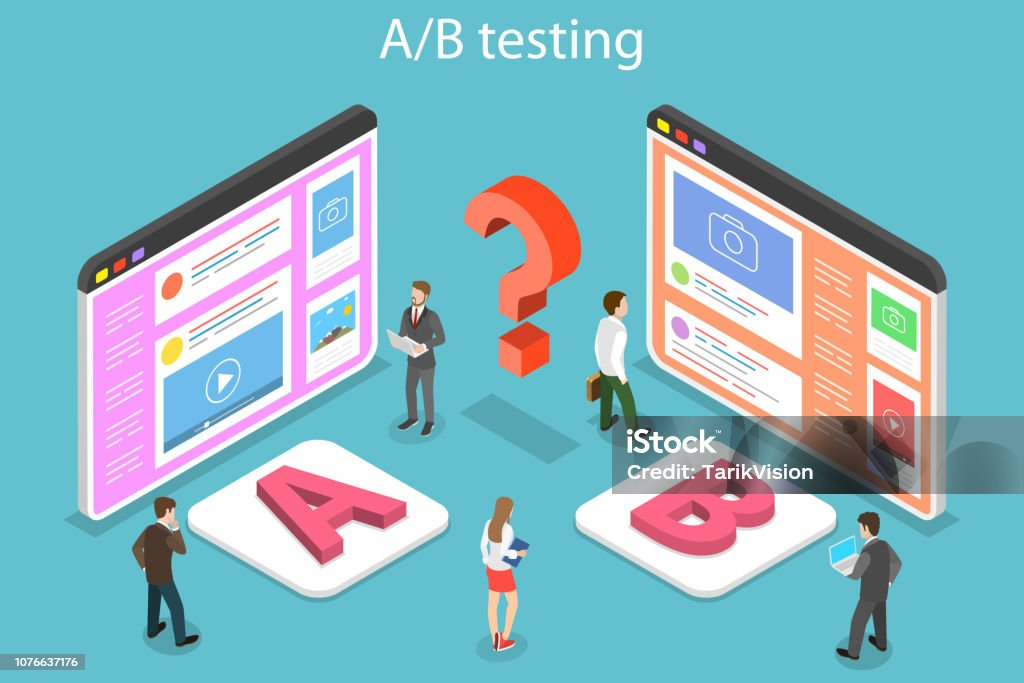

У нас є дані про маркетингову кампанію, де користувачі поділені на контрольну групу (Control) та тестову групу (Test).
Ми хочемо перевірити, чи має новий підхід (кампанія Test) кращий вплив на конверсію та поведінку користувачів у порівнянні зі старим підходом (кампанія Control).

# Завантаження та обробка даних

### Завантаження необхідних бібліотек для аналізу

In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import shapiro

from warnings import simplefilter
simplefilter("ignore")

### Завантажуємо дані контрольної групи

In [51]:
control_group = pd.read_csv("control_group.csv", sep=";", parse_dates=["Date"], dayfirst=True)
control_group.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,2019-08-05,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завантажуємо дані тестової групи

In [52]:
test_group = pd.read_csv("test_group.csv", sep=";", parse_dates=["Date"], dayfirst=True)
test_group.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Test Campaign,2019-08-01,3008,39550,35820,3038,1946,1069,894,255
1,Test Campaign,2019-08-02,2542,100719,91236,4657,2359,1548,879,677
2,Test Campaign,2019-08-03,2365,70263,45198,7885,2572,2367,1268,578
3,Test Campaign,2019-08-04,2710,78451,25937,4216,2216,1437,566,340
4,Test Campaign,2019-08-05,2297,114295,95138,5863,2106,858,956,768


### Для зручності перейменуємо колонки. Перевіряємо формат даних і наявність пропущених значень.

In [72]:
control_group.rename(columns= {"Campaign Name":"Назва кампанії", "Date": "Дата", "Spend [USD]": "Витрати в доларах", "Reach": "Охоплення", "# of Impressions": "Кількість показів", "# of Website Clicks": "Кількість кліків на сайт",
                     "# of Searches": "Кількість пошуків", "# of View Content": "Кількість переглядів",
                     "# of Add to Cart": "Кількість додавань у кошик", "# of Purchase": "Кількість покупок"}, inplace=True)

In [73]:
test_group.rename(columns= {"Campaign Name":"Назва кампанії", "Date": "Дата", "Spend [USD]": "Витрати в доларах", "Reach": "Охоплення", "# of Impressions": "Кількість показів", "# of Website Clicks": "Кількість кліків на сайт",
                     "# of Searches": "Кількість пошуків", "# of View Content": "Кількість переглядів",
                     "# of Add to Cart": "Кількість додавань у кошик", "# of Purchase": "Кількість покупок"}, inplace=True)

In [55]:
control_group.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Назва кампанії              30 non-null     object        
 1   Дата                        30 non-null     datetime64[ns]
 2   Витрати в доларах           30 non-null     int64         
 3   Kількість показів           29 non-null     float64       
 4   Охоплення                   29 non-null     float64       
 5   Кількість кліків на сайт    29 non-null     float64       
 6   Кількість пошуків           29 non-null     float64       
 7   Кількість переглядів        29 non-null     float64       
 8   Кількість додавань у кошик  29 non-null     float64       
 9   Кількість покупок           29 non-null     float64       
dtypes: datetime64[ns](1), float64(7), int64(1), object(1)
memory usage: 2.5+ KB


In [56]:
test_group.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Назва кампанії              30 non-null     object        
 1   Дата                        30 non-null     datetime64[ns]
 2   Витрати в доларах           30 non-null     int64         
 3   Kількість показів           30 non-null     int64         
 4   Охоплення                   30 non-null     int64         
 5   Кількість кліків на сайт    30 non-null     int64         
 6   Кількість пошуків           30 non-null     int64         
 7   Кількість переглядів        30 non-null     int64         
 8   Кількість додавань у кошик  30 non-null     int64         
 9   Кількість покупок           30 non-null     int64         
dtypes: datetime64[ns](1), int64(8), object(1)
memory usage: 2.5+ KB


У контрольній групі **відсутні дані за 4-й день**. Ми розглянули кілька варіантів вирішення цієї проблеми (заповнити пропущені значення, видалити день з аналізу, використати тестову групу для підстановки значень) і вирішили, що найкращим варіантом буде **заповнити відсутні значення середнім арифметичним**. Спочатку виберемо всі колонки з числовими значеннями, а потім заповнимо пропущені значення їхнім середнім значенням.

In [57]:
numeric_cols = control_group.select_dtypes(include=np.number).columns
control_group[numeric_cols] = control_group[numeric_cols].fillna(control_group[numeric_cols].mean())

In [58]:
control_group.head()

,Назва кампанії,Дата,Витрати в доларах,Kількість показів,Охоплення,Кількість кліків на сайт,Кількість пошуків,Кількість переглядів,Кількість додавань у кошик,Кількість покупок
0,Control Campaign,2019-08-01,2280,82702.000000,56930.000000,7016.000000,2290.000000,2159.000000,1819.0,618.000000
1,Control Campaign,2019-08-02,1757,121040.000000,102513.000000,8110.000000,2033.000000,1841.000000,1219.0,511.000000
2,Control Campaign,2019-08-03,2343,131711.000000,110862.000000,6508.000000,1737.000000,1549.000000,1134.0,372.000000
3,Control Campaign,2019-08-04,1940,72878.000000,61235.000000,3065.000000,1042.000000,982.000000,1183.0,340.000000
4,Control Campaign,2019-08-05,1835,109559.758621,88844.931034,5320.793103,2221.310345,1943.793103,1300.0,522.793103


In [59]:
display(f"Контрольна група має {control_group.shape[0]} рядків та {control_group.shape[1]} колонок.")
display(f"Тестова група має {test_group.shape[0]} рядків та {test_group.shape[1]} колонок.")

'Контрольна группа має 30 рядків та 10 колонок.'

'Тестова группа має 30 рядків та 10 колонок.'

### Розгляд значень у контрольній та тестовій групах перед основним аналізом

Пропоную переглянути значення у контрольній та тестовій групах, щоб оцінити їх розподіл та можливі відмінності між ними. Це допоможе краще зрозуміти дані перед проведенням подальшого аналізу.

In [60]:
control_group.describe().T

,count,mean,min,25%,50%,75%,max,std
Дата,30,2019-08-15 12:00:00,2019-08-01 00:00:00,2019-08-08 06:00:00,2019-08-15 12:00:00,2019-08-22 18:00:00,2019-08-30 00:00:00,NaN
Витрати в доларах,30.0,2288.433333,1757.0,1945.5,2299.5,2532.0,3083.0,367.334451
Kількість показів,30.0,109559.758621,71274.0,95191.25,112368.0,121259.0,145248.0,21311.695472
Охоплення,30.0,88844.931034,42859.0,75300.25,91418.0,101958.75,127852.0,21452.627592
Кількість кліків на сайт,30.0,5320.793103,2277.0,4122.25,5272.396552,6609.5,8137.0,1726.803732
Кількість пошуків,30.0,2221.310345,1001.0,1629.25,2340.0,2655.0,4891.0,851.025795
Кількість переглядів,30.0,1943.793103,848.0,1249.0,1979.5,2360.5,4219.0,764.021907
Кількість додавань у кошик,30.0,1300.0,442.0,942.5,1319.5,1638.0,1913.0,400.371207
Кількість покупок,30.0,522.793103,222.0,375.5,506.0,663.25,800.0,181.810508


In [61]:
test_group.describe().T

,count,mean,min,25%,50%,75%,max,std
Дата,30,2019-08-15 12:00:00,2019-08-01 00:00:00,2019-08-08 06:00:00,2019-08-15 12:00:00,2019-08-22 18:00:00,2019-08-30 00:00:00,NaN
Витрати в доларах,30.0,2563.066667,1968.0,2324.5,2584.0,2836.25,3112.0,348.687681
Kількість показів,30.0,74584.8,22521.0,47541.25,68853.5,99500.0,133771.0,32121.377422
Охоплення,30.0,53491.566667,10598.0,31516.25,44219.5,78778.75,109834.0,28795.775752
Кількість кліків на сайт,30.0,6032.333333,3038.0,4407.0,6242.5,7604.75,8264.0,1708.567263
Кількість пошуків,30.0,2418.966667,1854.0,2043.0,2395.5,2801.25,2978.0,388.742312
Кількість переглядів,30.0,1858.0,858.0,1320.0,1881.0,2412.0,2801.0,597.654669
Кількість додавань у кошик,30.0,881.533333,278.0,582.5,974.0,1148.5,1391.0,347.584248
Кількість покупок,30.0,521.233333,238.0,298.0,500.0,701.0,890.0,211.047745


Основні відмінності між групами: На тестову групу витрачено **більше коштів**, ніж на контрольну. При цьому **кількість показів, охоплення, переглядів контенту та додавань у кошик у тестовій групі суттєво нижча**. Кількість **кліків на сайт та пошуків** – навпаки, вища у тестовій групі. **Кількість покупок** майже **однакова** в обох групах.


Пропоную об’єднати ці дві групи в одну таблицю.

In [74]:
concat_table = pd.concat([control_group, test_group])

На наступному етапі будуть **представлені візуалізації**, які допоможуть краще зрозуміти основні висновки з аналізу даних. Використовуватимемо графіки для порівняння показників між контрольними та тестовими групами.

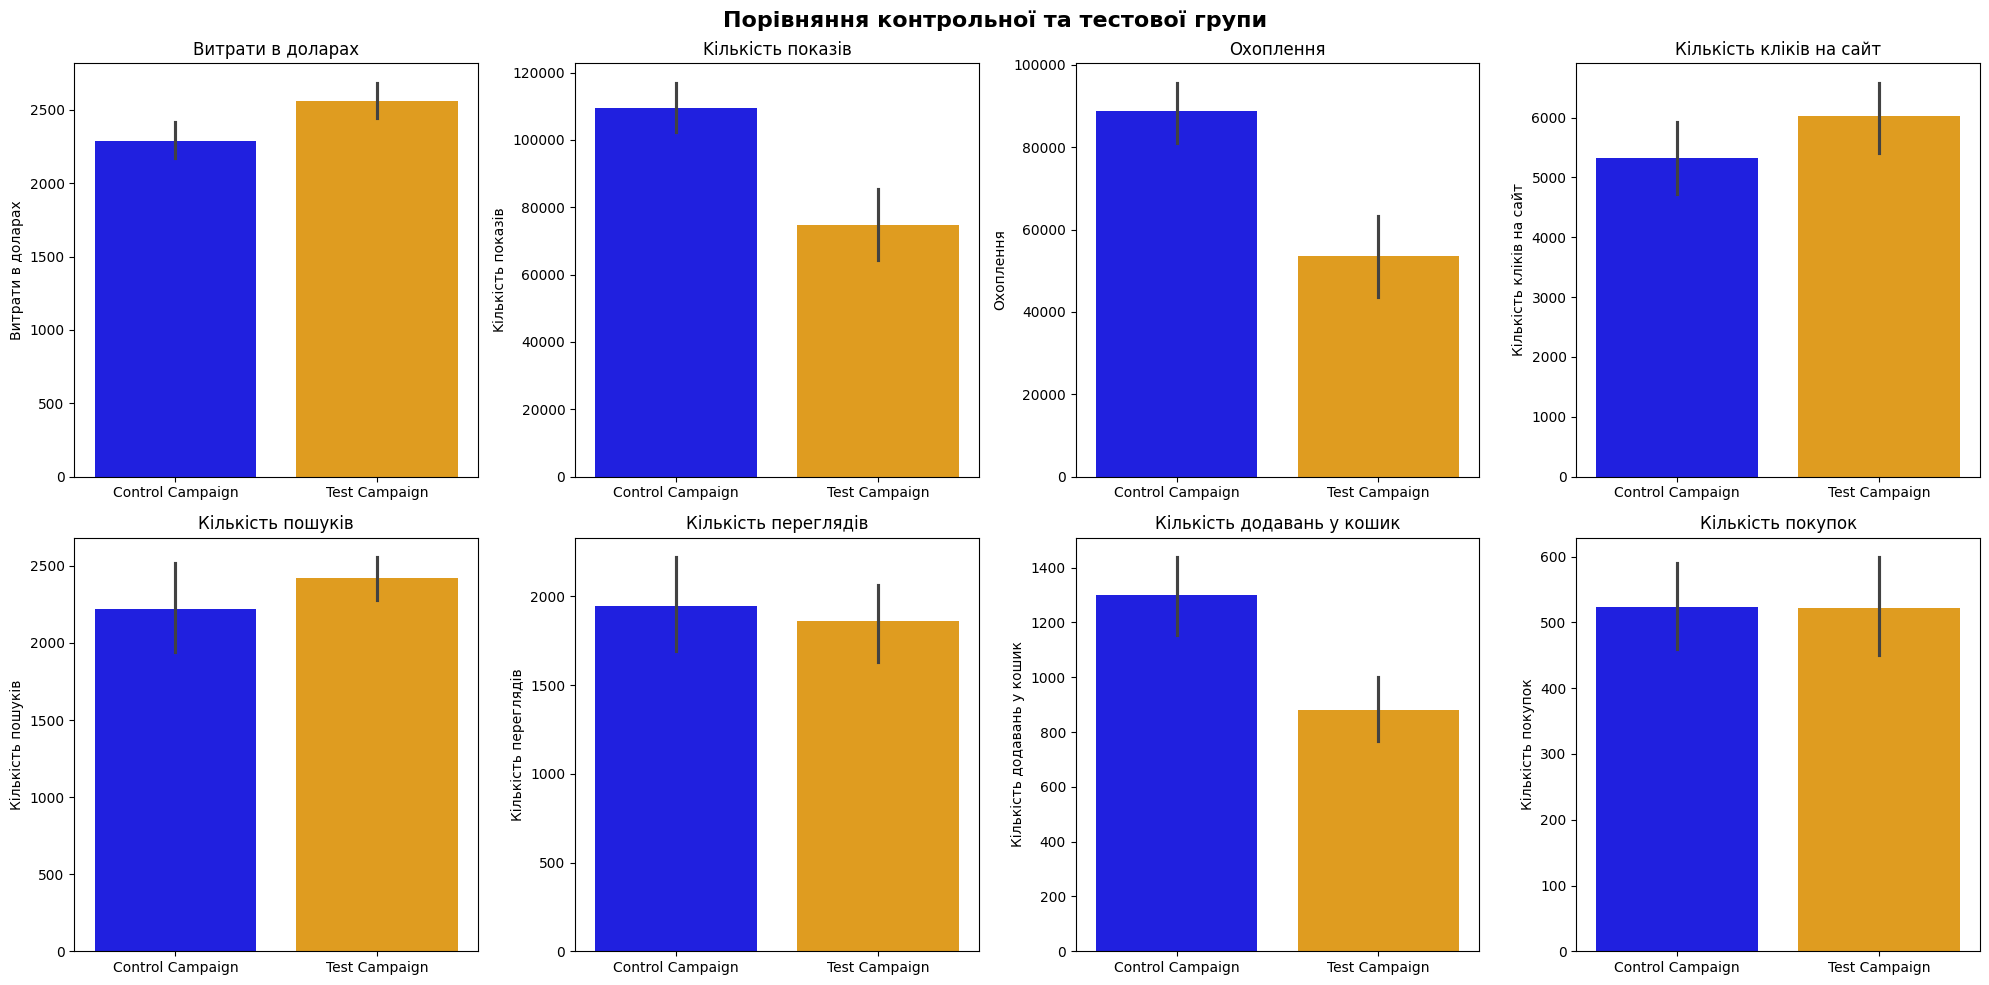

In [75]:
metrics = ["Витрати в доларах", "Kількість показів", "Охоплення",
           "Кількість кліків на сайт", "Кількість пошуків",
           "Кількість переглядів", "Кількість додавань у кошик", "Кількість покупок"]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Порівняння контрольної та тестової групи", fontsize=16, fontweight='bold')

for i, metric in enumerate(metrics):  # Тут правильне ім'я змінної
    row, col = divmod(i, 4)
    sns.barplot(data=concat_table, x="Назва кампанії", y=metric, ax=axes[row, col], palette=["blue", "orange"])
    axes[row, col].set_title(metric)
    axes[row, col].set_xlabel("")

plt.tight_layout()

### Розрахуємо потрібні метрики для аналізу

In [86]:
concat_table["Коефіцієнт клікабельності"] = concat_table["Кількість кліків на сайт"] / concat_table["Kількість показів"]
concat_table["Коефіцієнт перегляду контенту"] = concat_table["Кількість переглядів"] / concat_table["Kількість показів"]
concat_table["Коефіцієнт конверсії"] = concat_table["Кількість покупок"] / concat_table["Kількість показів"]
concat_table["Ціна показів"] = concat_table["Витрати в доларах"] / concat_table["Kількість показів"]
concat_table["Ціна покупки"] = concat_table["Витрати в доларах"] / concat_table["Кількість покупок"]


In [87]:
concat_table.pivot_table(index="Назва кампанії", values=["Коефіцієнт клікабельності", "Коефіцієнт перегляду контенту", "Коефіцієнт конверсії", "Ціна показів", "Ціна покупки"], aggfunc="mean")

,Коефіцієнт клікабельності,Коефіцієнт конверсії,Коефіцієнт перегляду контенту,Ціна показів,Ціна покупки
Назва кампанії,,,,,
Control Campaign,0.050879,0.004993,0.018769,0.021550,5.000927
Test Campaign,0.102423,0.008425,0.031505,0.042681,5.899589


Результати тестування показують, що тестова група демонструє суттєве покращення в ключових метриках, таких як коефіцієнт клікабельності, конверсії та перегляду контенту, що вказує на вищу ефективність нової маркетингової кампанії. Проте, варто зазначити, що вартість показів і покупки виявилася вищою, що потребує додаткового аналізу з точки зору витрат на кампанію. Загалом, новий підхід (Test Campaign) є обіцяючим з точки зору ефективності, але для оптимізації бюджету важливо зосередитися на контролі витрат для досягнення оптимального співвідношення ціна-якість.

### Чи є метричні змінні нормальними розподіленими чи ні?

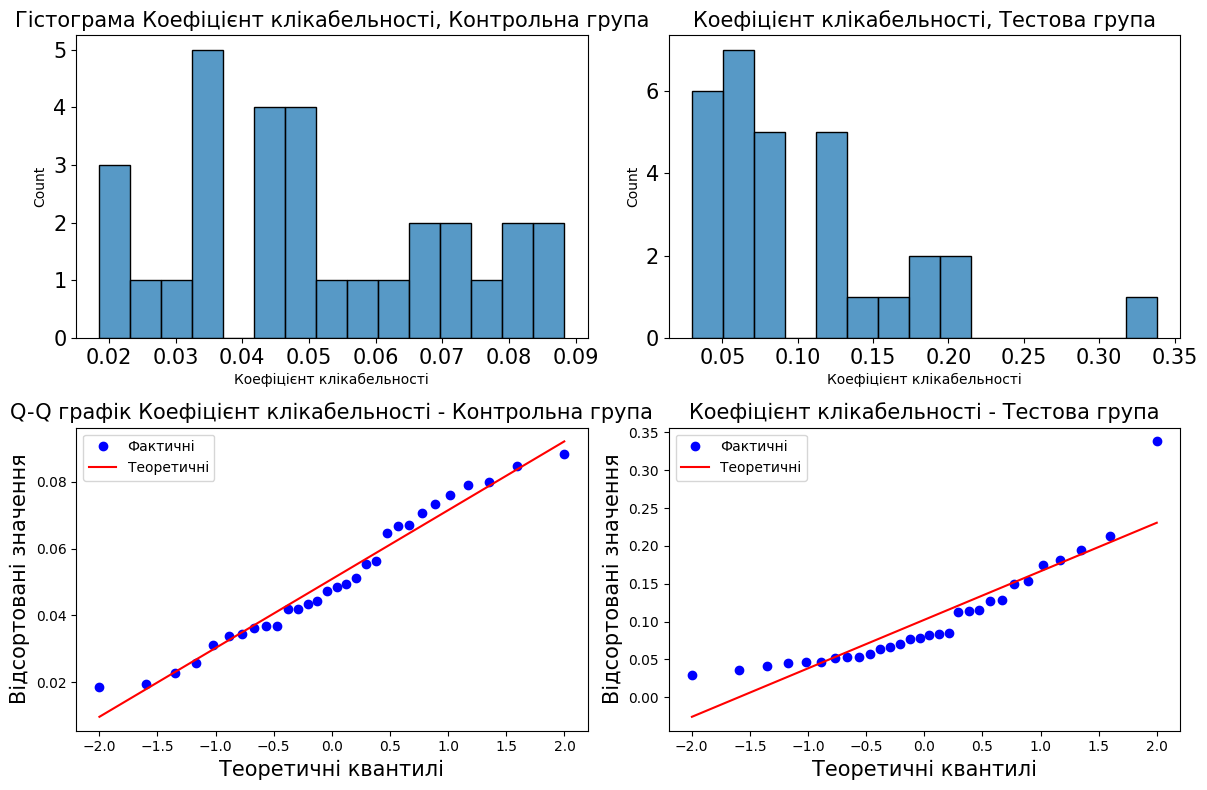

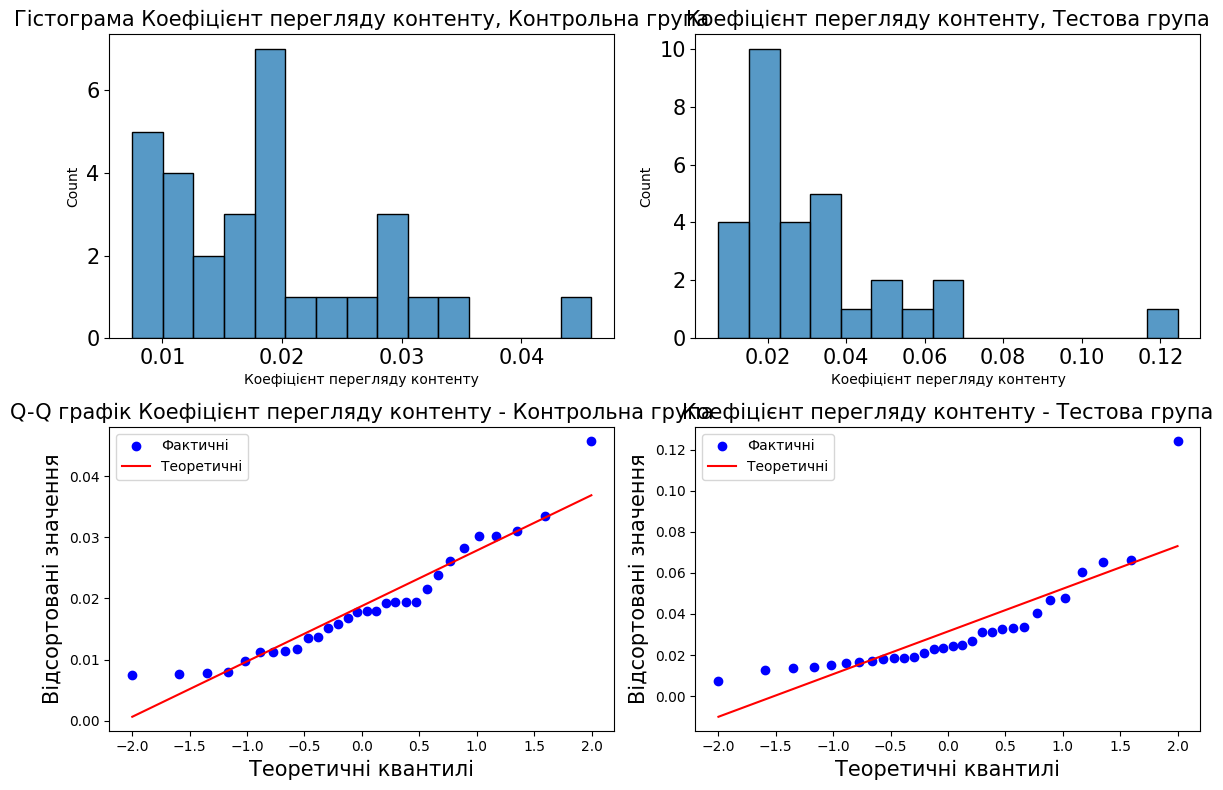

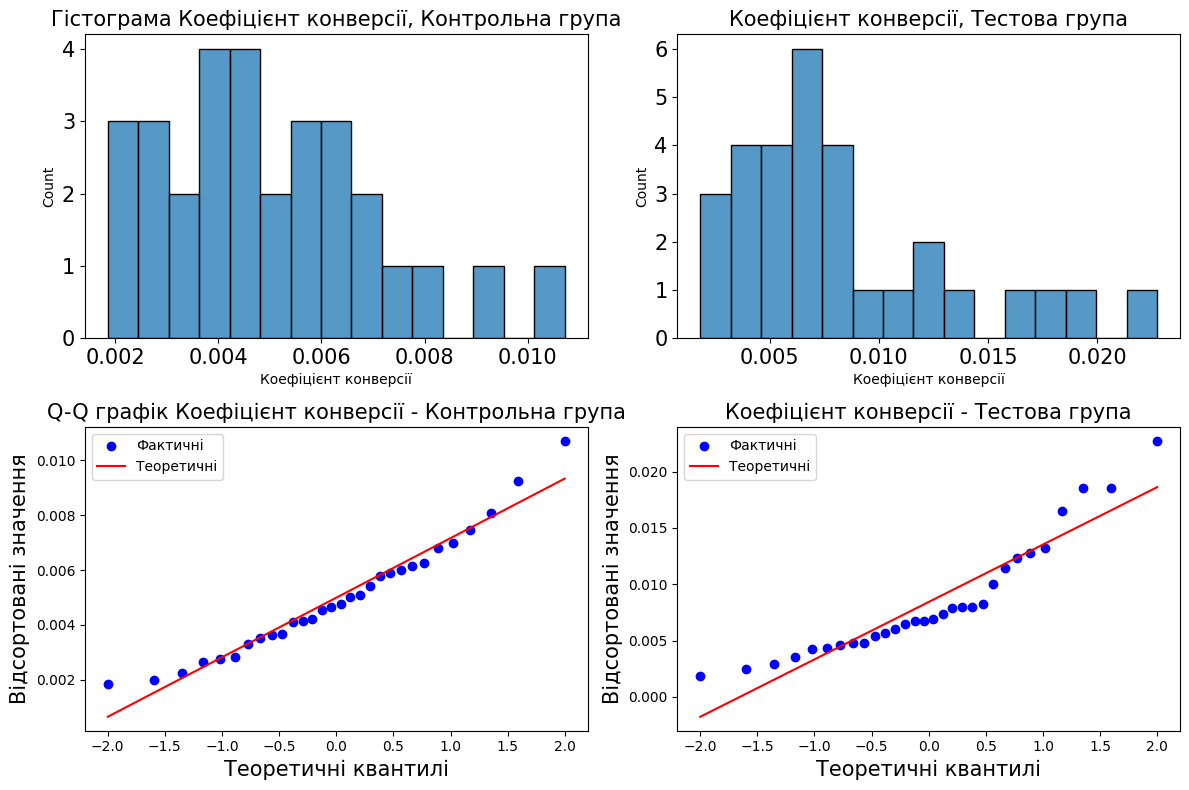

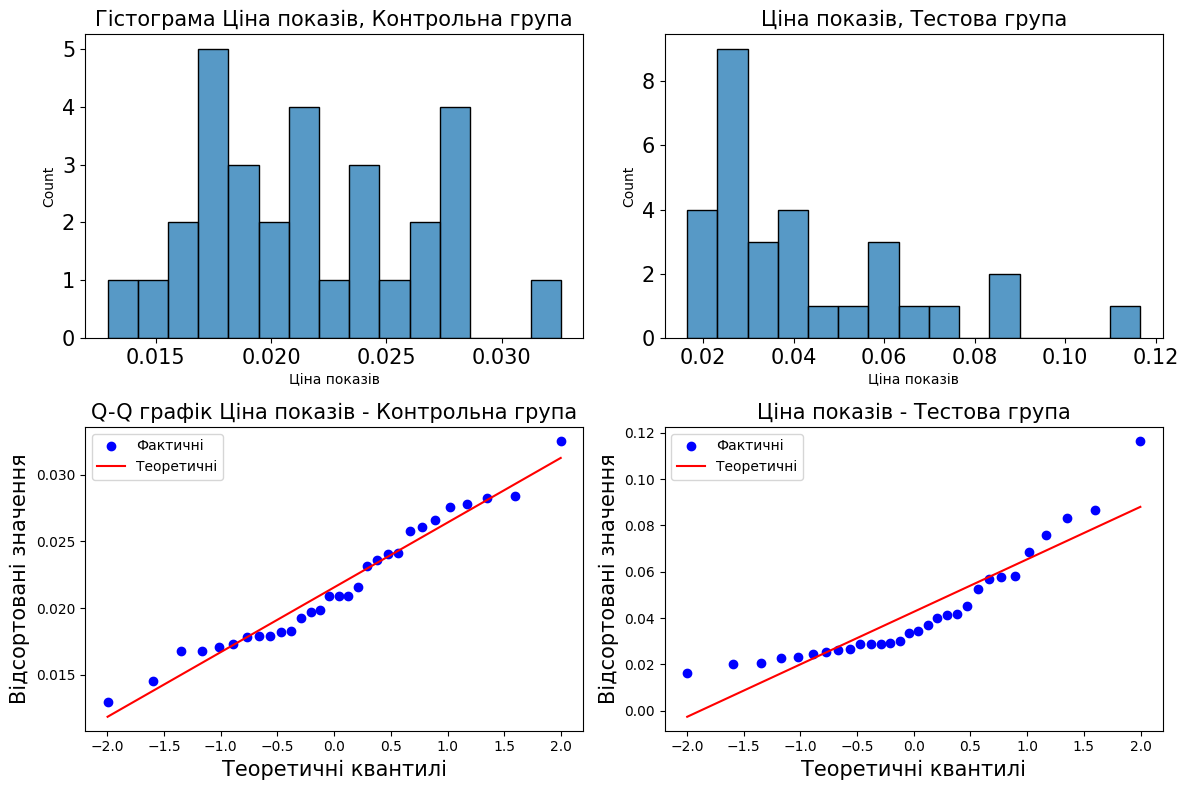

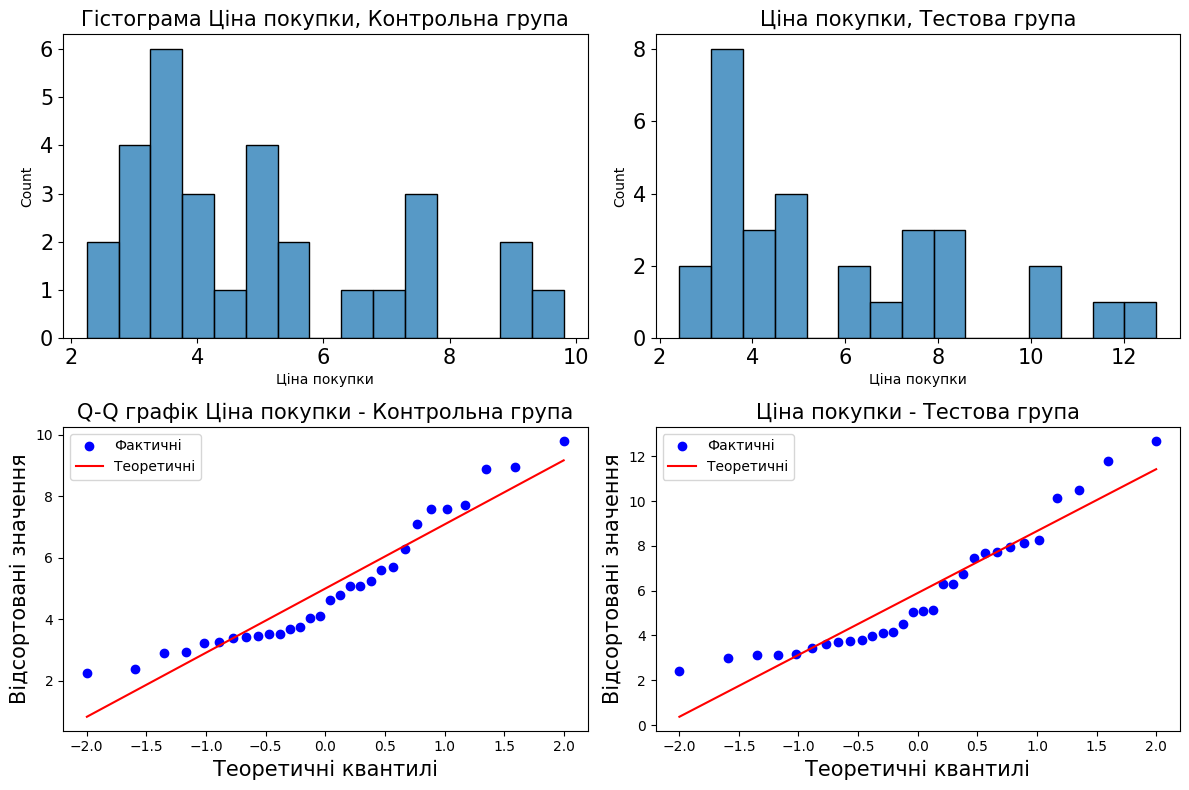

In [106]:
metrics = ["Коефіцієнт клікабельності", "Коефіцієнт перегляду контенту", "Коефіцієнт конверсії", "Ціна показів", "Ціна покупки"]

for metric in metrics:

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    sns.histplot(concat_table[concat_table['Назва кампанії'] == 'Control Campaign'][metric], bins=15, ax=axes[0, 0])
    axes[0, 0].xaxis.set_tick_params(labelsize=15)
    axes[0, 0].yaxis.set_tick_params(labelsize=15)
    axes[0, 0].set_title(f"Гістограма {metric}, Контрольна група", fontsize=15)

    sns.histplot(concat_table[concat_table['Назва кампанії'] == 'Test Campaign'][metric], bins=15, ax=axes[0, 1])
    axes[0, 1].xaxis.set_tick_params(labelsize=15)
    axes[0, 1].yaxis.set_tick_params(labelsize=15)
    axes[0, 1].set_title(f"{metric}, Тестова група", fontsize=15)

    stats.probplot(concat_table[concat_table['Назва кампанії'] == 'Control Campaign'][metric], dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title(f"Q-Q графік {metric} - Контрольна група", fontsize=15)
    axes[1, 0].set_xlabel("Теоретичні квантилі", fontsize=15)
    axes[1, 0].set_ylabel("Відсортовані значення", fontsize=15)
    axes[1, 0].legend(['Фактичні', 'Теоретичні'])

    stats.probplot(concat_table[concat_table['Назва кампанії'] == 'Test Campaign'][metric], dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title(f"{metric} - Тестова група", fontsize=15)
    axes[1, 1].set_xlabel("Теоретичні квантилі", fontsize=15)
    axes[1, 1].set_ylabel("Відсортовані значення", fontsize=15)
    axes[1, 1].legend(['Фактичні', 'Теоретичні'])

    plt.tight_layout()


За результатами аналізу графіків ми можемо зробити висновок, що метрики не мають нормальних розподілів. На гістограмі, яка повинна мати форму дзвінка, ми спостерігаємо відсутність цієї форми. Крім того, на QQ-графіку точки не відповідають червоній лінії, що є ознакою відсутності нормальності. Деякі з розподілів виглядають перекрученими, що, ймовірно, можна пояснити обмеженою кількістю даних у кампанії.

### Тестування

**Тест Шапіро-Вілька** — це статистичний тест, який використовується для перевірки нормальності розподілу даних. Він допомагає визначити, чи можна вважати, що вибірка походить з нормально розподіленої популяції.

In [111]:
for metric in metrics:

    print(f'\n{metric}:')

    test_stat, pvalue = shapiro(concat_table[concat_table['Назва кампанії'] == 'Control Campaign'][metric])
    print('Test Stat = %.4f, p-value = %.4f' % (test_stat, pvalue))

    test_stat, pvalue = shapiro(concat_table[concat_table['Назва кампанії'] == 'Test Campaign'][metric])
    print('Test Stat = %.4f, p-value = %.4f' % (test_stat, pvalue))


Коефіцієнт клікабельності:
Test Stat = 0.9583, p-value = 0.2807
Test Stat = 0.8409, p-value = 0.0004

Коефіцієнт перегляду контенту:
Test Stat = 0.9187, p-value = 0.0248
Test Stat = 0.7473, p-value = 0.0000

Коефіцієнт конверсії:
Test Stat = 0.9578, p-value = 0.2723
Test Stat = 0.8838, p-value = 0.0035

Ціна показів:
Test Stat = 0.9630, p-value = 0.3678
Test Stat = 0.8486, p-value = 0.0006

Ціна покупки:
Test Stat = 0.9049, p-value = 0.0111
Test Stat = 0.8966, p-value = 0.0069


**Коефіцієнт клікабельності:**
Для контрольної групи: p-value = 0.2807, що вказує на **нормальність розподіл**у.
Для тестової групи: p-value = 0.0004, що свідчить про **ненормальність розподілу**.

**Коефіцієнт перегляду контенту:**
Для контрольної групи: p-value = 0.0248, що вказує на **ненормальність**.
Для тестової групи: p-value = 0.0000, що також свідчить про **ненормальність**.

**Коефіцієнт конверсії:**
Для контрольної групи: p-value = 0.2723, що вказує **на нормальність розподілу**.
Для тестової групи: p-value = 0.0035, що вказує на **ненормальність розподілу**.

Ціна показів:
Для контрольної групи: p-value = 0.3678, що вказує на **нормальність розподілу**.
Для тестової групи: p-value = 0.0006, що вказує на **ненормальність**.

Ціна покупки:
Для контрольної групи: p-value = 0.0111, що вказує на **ненормальність розподілу.**

Для тестової групи: p-value = 0.0069, що також свідчить про **ненормальність розподілу.**

**Висновок:** Для контрольних груп деякі метрики (Коефіцієнт клікабельності, Коефіцієнт конверсії, Ціна показів) мають p-value > 0.05, що свідчить про нормальність розподілу. Але для тестових груп усі ці метрики мають p-value < 0.05, що означає, що їхні дистрибуції не є нормальними.

Враховуючи, що розмір вибірки невеликий, а розподіли, які я розглядаю, перекошені, t-тест може бути не надійним. Це пояснюється тим, що центральна гранична теорема (яка може допомогти виправдати t-тест для перекошених змінних) повинна мати більші значення розміру вибірки.

Перевірка гіпотез

Нульова гіпотеза (H0). С**уттєвої різниці** між продуктивністю контрольної групи та тестової групи **немає**.

Альтернативна гіпотеза (H1). **Є суттєва різниця** між продуктивністю контрольної групи та тестової.

In [119]:
for metric in metrics:

    print(f'\n{metric}:')
    t_stat, p_value = stats.ttest_ind(concat_table[concat_table['Назва кампанії'] == 'Control Campaign'][metric], concat_table[concat_table['Назва кампанії'] == 'Test Campaign'][metric])
    print(f"T-statistic: {t_stat}, P-value: {p_value}")


Коефіцієнт клікабельності:
T-statistic: -3.9962501835865276, P-value: 0.00018398526312426124

Коефіцієнт перегляду контенту:
T-statistic: -2.7743737957457926, P-value: 0.007429253084171041

Коефіцієнт конверсії:
T-statistic: -3.336143277653973, P-value: 0.0014863795787692907

Ціна показів:
T-statistic: -4.778365736857713, P-value: 1.2457700607921947e-05

Ціна покупки:
T-statistic: -1.406289257896576, P-value: 0.16497351064327181


Для Коефіцієнта клікабельності, Коефіцієнта перегляду контенту, Коефіцієнта конверсії та Ціни показів різниці між групами є статистично значущими (p-value < 0.05), що свідчить про вплив тестової кампанії на ці показники.
Для Ціни покупки p-value > 0.05, що означає відсутність значущих змін між контрольними і тестовими групами за цією метрикою.
Усі t-statistic мають від’ємні значення, що вказує на те, що середнє значення тестової групи є меншим, ніж середнє контрольної групи для всіх метрик.

# Загальний висновок


У процесі аналізу ми спостерігали статистично **значущі відмінності для коефіцієнтів клікабельності, перегляду контенту, конверсії та ціни показів між контрольними та тестовими групами**. Це свідчить про покращення результатів тестової кампанії в порівнянні з контрольними показниками. Водночас **для ціни покупки не було виявлено статистично значущої різниці**, що означає, що новий підхід (тестова кампанія) не має істотного впливу на цей параметр.

Ці спостереження дозволяють зробити висновок, **що нова кампанія** (Test Campaign) **позитивно вплинула на більшість метрик, окрім ціни покупки**. Всі ці результати були зафіксовані протягом всього аналізу, що дозволяє зробити обґрунтовані висновки про ефективність кампанії.

### Рекомендаціі

На основі проведеного аналізу та статистичних результатів, маю наступні рекомендації:

1. **Оптимізація маркетингової стратегії:**
Оскільки коефіцієнти клікабельності (CTR), перегляду контенту та конверсії показали значне покращення в тестовій групі, це свідчить про те, що нова кампанія (Test Campaign) є ефективною у залученні користувачів та сприяє більшій активності. Рекомендується продовжити впровадження тестової кампанії для подальшого підвищення ефективності.

2. **Покращення взаємодії з користувачами:**
Зважаючи на покращення коефіцієнтів перегляду контенту та конверсії, є сенс в подальшій оптимізації контенту кампанії, щоб ще більше залучити користувачів і збільшити конверсії. Можливо, варто доопрацювати креативи та повідомлення, що демонструються користувачам, щоб досягти кращих результатів у взаємодії з продуктом.
3. **Аналіз витрат на рекламу:**
Ціна показів в тестовій групі виявилася вищою, що вимагає додаткового аналізу. Оскільки підвищена вартість показів може негативно впливати на рентабельність кампанії, рекомендується вивчити механізми оптимізації витрат на рекламу, щоб зберегти баланс між ефективністю та витратами.
4. **Подальший моніторинг ціни покупки:**
Результати тесту не показали статистично значущої різниці в цінові покупки. Це може вказувати на те, що зміни в кампанії не мали істотного впливу на цей параметр. Рекомендується проводити додаткові аналізи, щоб визначити можливі фактори, які можуть вплинути на ціну покупки, або звернути увагу на інші аспекти рекламної кампанії для досягнення бажаного результату в цьому напрямку.
5. **Подальші експерименти та тестування:**
Для більш глибокого розуміння впливу нової кампанії на всі ключові метрики, рекомендується провести додаткові A/B тести або аналізи з використанням інших змінних, щоб точно оцінити її ефективність та знайти шляхи для подальшої оптимізації.

Загалом, нова кампанія (Test Campaign) демонструє позитивні результати в ряді важливих метрик, що свідчить про її ефективність. Однак варто звернути увагу на питання оптимізації витрат та подальшого вдосконалення кампанії для максимізації результатів.